**Imports**

In [ ]:
import requests
from bs4 import BeautifulSoup

import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
nltk.download('stopwords')

from nltk.probability import FreqDist
from nltk.util import ngrams

from wordcloud import WordCloud
import matplotlib.pyplot as plt

from nltk.stem import PorterStemmer

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

import pandas as pd
import json

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
from google.colab import files
files.upload()

Saving news_data_dict.json to news_data_dict.json


{'news_data_dict.json': b'{\n    "debate_1": {\n        "BBC": "This may have been the debate Donald Trump wanted, but it wasn\'t the one he needed. With one last chance to make a pitch to the American public that he should be trusted with the presidency, the Republican nominee had to make efforts to expand his base of support.  He had to find a way to distance himself from the allegation that he has a history of sexual harassment.  He had to position himself as the change candidate - just days after a Fox poll showed that Hillary Clinton, whose party has held the presidency for eight years, was beating him on the question of who would \\"change the country for the better\\". Instead, after roughly half an hour of something resembling an actual policy debate about the Supreme Court, gun rights, abortion and even immigration, the old Donald Trump - the one who constantly interrupted his opponent, sparred with the moderator and lashed out at enemies real and perceived - emerged. He calle

In [ ]:
import json

# Opening JSON file
f = open('news_data_dict.json')

# returns JSON object as
# a dictionary
data = json.load(f)


In [ ]:
data

{'debate_1': {'BBC': 'This may have been the debate Donald Trump wanted, but it wasn\'t the one he needed. With one last chance to make a pitch to the American public that he should be trusted with the presidency, the Republican nominee had to make efforts to expand his base of support.  He had to find a way to distance himself from the allegation that he has a history of sexual harassment.  He had to position himself as the change candidate - just days after a Fox poll showed that Hillary Clinton, whose party has held the presidency for eight years, was beating him on the question of who would "change the country for the better". Instead, after roughly half an hour of something resembling an actual policy debate about the Supreme Court, gun rights, abortion and even immigration, the old Donald Trump - the one who constantly interrupted his opponent, sparred with the moderator and lashed out at enemies real and perceived - emerged. He called Mrs Clinton a liar and a "nasty woman".  He 

In [ ]:
data.keys()

dict_keys(['debate_1', 'debate_2', 'debate_3', 'post_election'])

## Intial Preprocessing

In [ ]:
#### output
data_preprocessed = {'debate_1': {}, 'debate_2': {}, 'debate_3': {}, 'post_election': {}}

#### Stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))
stop_words.add('said')
stop_words.add('continue')
stop_words.add('percent')
stop_words.add('year')
stop_words.add('mr')
stop_words.add('mrs')
stop_words.add('.')
stop_words.add('mr')
stop_words.add('``')
stop_words.add("''")
stop_words.add(",")
stop_words.add("n't")
stop_words.add(":")
stop_words.add("'")
stop_words.add("-")
stop_words.add("'s")
stop_words.add("?")
stop_words.add("“")
stop_words.add("”")
stop_words.add("’")
stop_words.add("–")
stop_words.add("--")
stop_words.add("%")
stop_words.add("—")

#############
for debate in data.keys():

    print(debate)
    print()

    for newspaper in data[debate]:
        print(newspaper)

        data[debate][newspaper] =  data[debate][newspaper].strip().lower() # strip and lowercase

        tokens = word_tokenize(data[debate][newspaper]) # Tokenize the lowercase text

        filtered_tokens = [word for word in tokens if word not in stop_words] # Filter out stopwords from the tokens

        freq_dist = FreqDist(filtered_tokens) # Calculate frequency distribution of words
        for word, frequency in freq_dist.most_common(10):
          print(f'{word}: {frequency}')
        bigrams = list(ngrams(filtered_tokens, 2)) # Generate bigrams

        # Save the preprocessed data in the data_preprocessed dictionary
        data_preprocessed[debate][newspaper] = {}
        data_preprocessed[debate][newspaper]['tokens'] = tokens
        data_preprocessed[debate][newspaper]['filtered_tokens'] = filtered_tokens
        data_preprocessed[debate][newspaper]['freq_dist'] = freq_dist
        data_preprocessed[debate][newspaper]['bigrams'] = bigrams
        print("--------")

    print("-"*50)


debate_1

BBC
trump: 32
clinton: 32
debate: 16
one: 8
women: 7
donald: 6
republican: 6
would: 6
election: 6
foundation: 6
--------
FOX
trump: 29
clinton: 28
debate: 14
bring: 5
back: 5
secretary: 5
state: 5
campaign: 5
data: 4
provided: 4
--------
NYT
mr.: 46
trump: 38
clinton: 29
mrs.: 26
debate: 9
obama: 9
would: 7
say: 7
voters: 6
also: 6
--------
WSJ
trump: 28
clinton: 22
mr.: 17
mrs.: 12
hillary: 9
donald: 7
voters: 6
monday: 5
people: 5
would: 5
--------
LA
trump: 18
clinton: 14
debate: 8
presidential: 6
first: 5
one: 5
would: 5
rosie: 4
fact: 4
monday: 3
--------
--------------------------------------------------
debate_2

BBC
trump: 25
clinton: 23
debate: 16
us: 9
would: 8
policy: 7
candidates: 6
exchange: 5
played: 5
often: 5
--------
FOX
trump: 29
clinton: 28
debate: 14
bring: 5
back: 5
secretary: 5
state: 5
campaign: 5
data: 4
provided: 4
--------
NYT
mr.: 40
trump: 36
clinton: 36
mrs.: 28
debate: 14
women: 7
one: 7
audience: 5
even: 5
years: 5
--------
WSJ
trump: 19
clinton

In [ ]:
data_preprocessed.keys()

dict_keys(['debate_1', 'debate_2', 'debate_3', 'post_election'])

In [ ]:
data_preprocessed['debate_1'].keys()

dict_keys(['BBC', 'FOX', 'NYT', 'WSJ', 'LA'])

In [ ]:
data_preprocessed['debate_1']['BBC'].keys()

dict_keys(['tokens', 'filtered_tokens', 'freq_dist', 'bigrams'])

In [ ]:
data_preprocessed['debate_1']['BBC']['filtered_tokens']

['may',
 'debate',
 'donald',
 'trump',
 'wanted',
 'one',
 'needed',
 'one',
 'last',
 'chance',
 'make',
 'pitch',
 'american',
 'public',
 'trusted',
 'presidency',
 'republican',
 'nominee',
 'make',
 'efforts',
 'expand',
 'base',
 'support',
 'find',
 'way',
 'distance',
 'allegation',
 'history',
 'sexual',
 'harassment',
 'position',
 'change',
 'candidate',
 'days',
 'fox',
 'poll',
 'showed',
 'hillary',
 'clinton',
 'whose',
 'party',
 'held',
 'presidency',
 'eight',
 'years',
 'beating',
 'question',
 'would',
 'change',
 'country',
 'better',
 'instead',
 'roughly',
 'half',
 'hour',
 'something',
 'resembling',
 'actual',
 'policy',
 'debate',
 'supreme',
 'court',
 'gun',
 'rights',
 'abortion',
 'even',
 'immigration',
 'old',
 'donald',
 'trump',
 'one',
 'constantly',
 'interrupted',
 'opponent',
 'sparred',
 'moderator',
 'lashed',
 'enemies',
 'real',
 'perceived',
 'emerged',
 'called',
 'clinton',
 'liar',
 'nasty',
 'woman',
 'women',
 'accusing',
 'sexual',
 'h

-----

# Wordcloud

debate_1

BBC


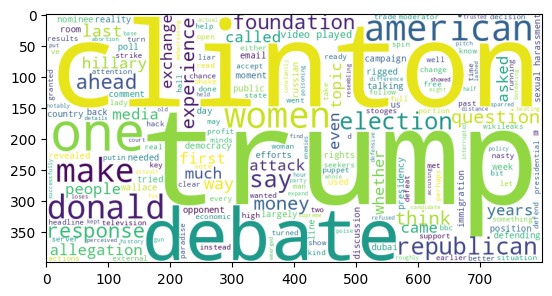

FOX


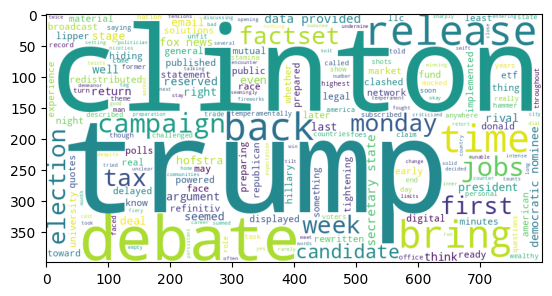

NYT


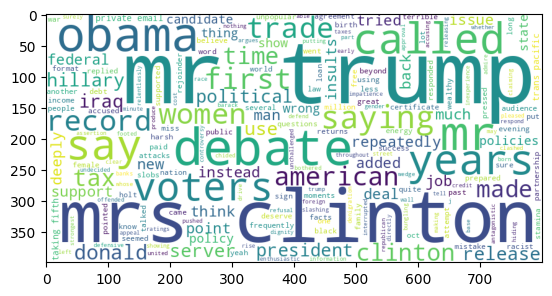

WSJ


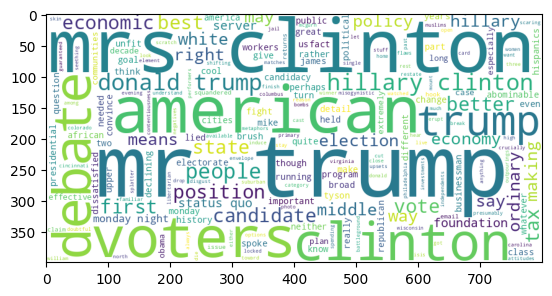

LA


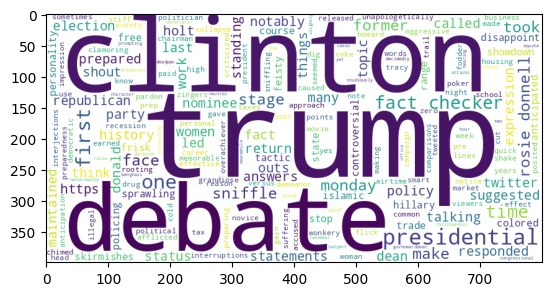

--------------------------------------------------
debate_2

BBC


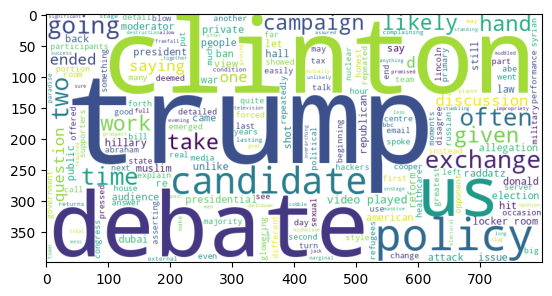

FOX


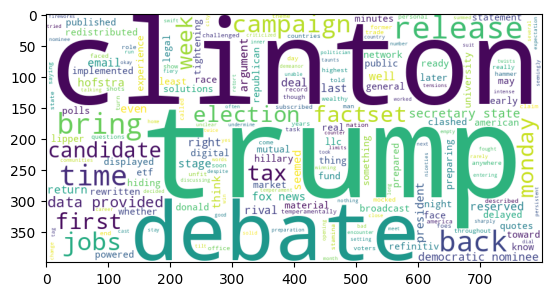

NYT


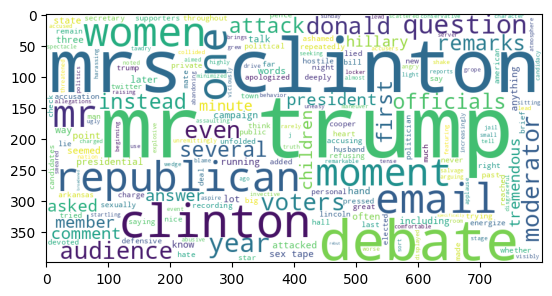

WSJ


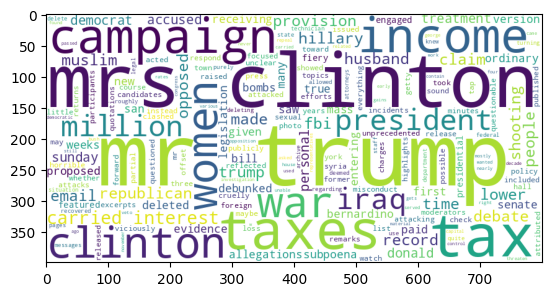

LA


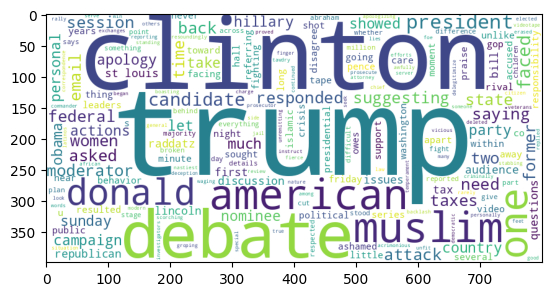

--------------------------------------------------
debate_3

BBC


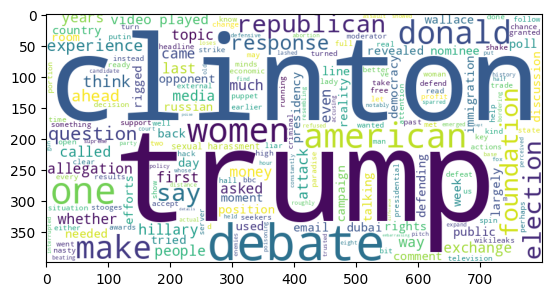

FOX


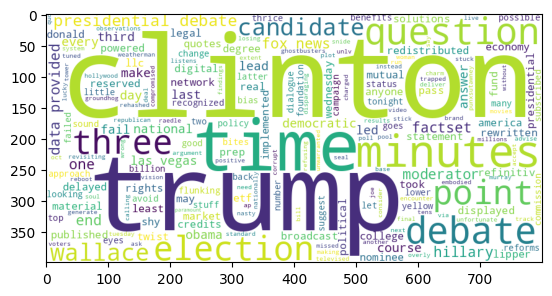

LA


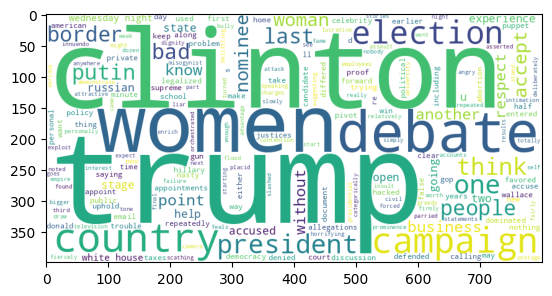

NYT


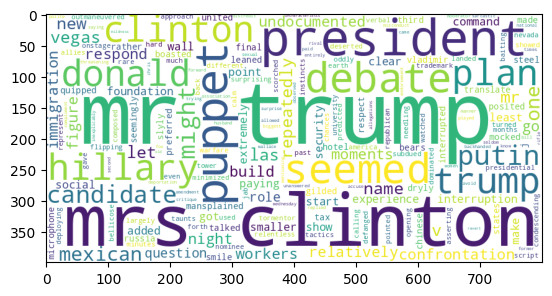

WSJ


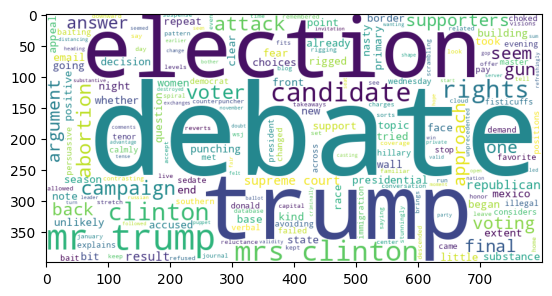

--------------------------------------------------
post_election

BBC


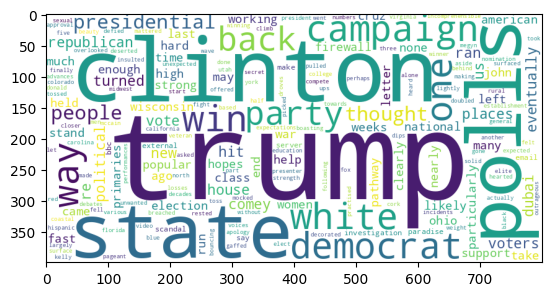

FOX


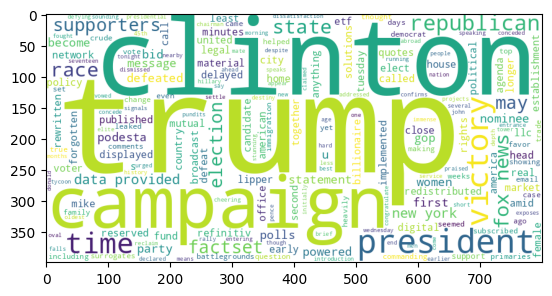

NYT


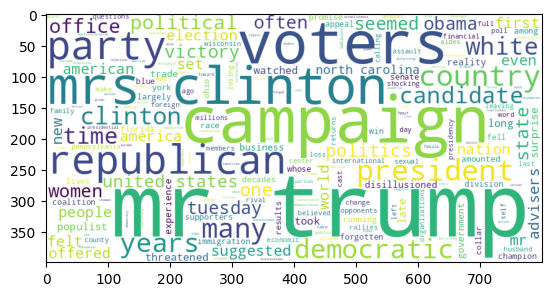

WSJ


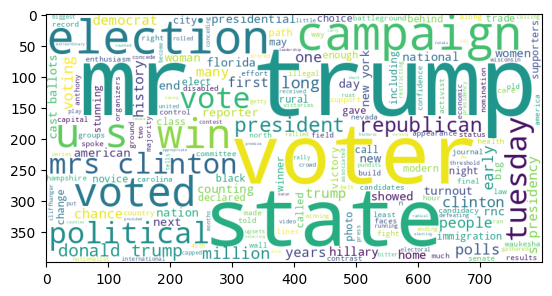

LA


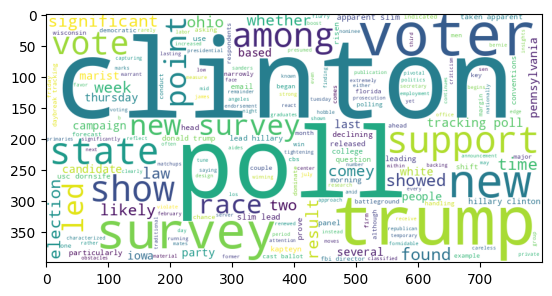

--------------------------------------------------


In [ ]:
for debate in data_preprocessed.keys():
    print(debate)
    print()


    for newspaper in data_preprocessed[debate].keys():
        print(newspaper)

        wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(data_preprocessed[debate][newspaper]['filtered_tokens']))
        plt.imshow(wordcloud)
        plt.show()

    print("-"*50)

Below focusing on news outlet as a whole

In [ ]:
data_preprocessed = {}

#### Stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))
stop_words.add('said')
stop_words.add('continue')
stop_words.add('percent')
stop_words.add('year')
stop_words.add('mr')
stop_words.add('mrs')
stop_words.add('.')
stop_words.add('mr')
stop_words.add('``')
stop_words.add("''")
stop_words.add(",")
stop_words.add("n't")
stop_words.add(":")
stop_words.add("'")
stop_words.add("-")
stop_words.add("'s")
stop_words.add("?")
stop_words.add("“")
stop_words.add("”")
stop_words.add("’")
stop_words.add("–")
stop_words.add("--")
stop_words.add("%")
stop_words.add("—")

for debate in data:
    for newspaper, text in data[debate].items():
        if newspaper not in data_preprocessed:
            data_preprocessed[newspaper] = {'tokens': [], 'filtered_tokens': []}

        text = text.strip().lower().replace('mr.', '')
        text = text.strip().lower().replace('mrs.', '')
        tokens = word_tokenize(text)
        filtered_tokens = [word for word in tokens if word not in stop_words]

        data_preprocessed[newspaper]['tokens'].extend(tokens)
        data_preprocessed[newspaper]['filtered_tokens'].extend(filtered_tokens)


for newspaper in data_preprocessed:
    freq_dist = FreqDist(data_preprocessed[newspaper]['filtered_tokens'])
    bigrams = list(ngrams(data_preprocessed[newspaper]['filtered_tokens'], 2))

    data_preprocessed[newspaper]['freq_dist'] = freq_dist

    print(f"{newspaper}:")
    for word, frequency in freq_dist.most_common(10):
        print(f'{word}: {frequency}')
    wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(' '.join(data_preprocessed[newspaper]['filtered_tokens']))
    plt.imshow(wordcloud)
    plt.show()
    print("-" * 50)





---



## Sentiment Analysis

In [ ]:
############################## Working

sentiment_intensity_analyzer_dict = {'debate': [],
                                     'newspaper': [],
                                     'neg': [],
                                     'neu': [],
                                     'pos': [],
                                     'compound': []}


sia = SentimentIntensityAnalyzer()
for debate in data_preprocessed.keys():
    print(debate)
    print()

    for newspaper in data_preprocessed[debate].keys():
        print(newspaper)

        # Analyze the sentiment of the sample text
        print(sia.polarity_scores(' '.join(data_preprocessed[debate][newspaper]['filtered_tokens'])))


        sentiment_intensity_analyzer_dict['debate'].append(debate)
        sentiment_intensity_analyzer_dict['newspaper'].append(newspaper)
        sentiment_intensity_analyzer_dict['neg'].append(sia.polarity_scores(' '.join(data_preprocessed[debate][newspaper]['filtered_tokens']))['neg'])
        sentiment_intensity_analyzer_dict['neu'].append(sia.polarity_scores(' '.join(data_preprocessed[debate][newspaper]['filtered_tokens']))['neu'])
        sentiment_intensity_analyzer_dict['pos'].append(sia.polarity_scores(' '.join(data_preprocessed[debate][newspaper]['filtered_tokens']))['pos'])
        sentiment_intensity_analyzer_dict['compound'].append(sia.polarity_scores(' '.join(data_preprocessed[debate][newspaper]['filtered_tokens']))['compound'])

        print("---------")
    print("-"*50)

debate_1

BBC
{'neg': 0.148, 'neu': 0.708, 'pos': 0.144, 'compound': -0.8078}
---------
FOX
{'neg': 0.118, 'neu': 0.757, 'pos': 0.126, 'compound': 0.5478}
---------
NYT
{'neg': 0.185, 'neu': 0.67, 'pos': 0.144, 'compound': -0.9928}
---------
WSJ
{'neg': 0.13, 'neu': 0.728, 'pos': 0.142, 'compound': 0.4334}
---------
LA
{'neg': 0.117, 'neu': 0.769, 'pos': 0.114, 'compound': 0.1872}
---------
--------------------------------------------------
debate_2

BBC
{'neg': 0.134, 'neu': 0.713, 'pos': 0.153, 'compound': 0.9536}
---------
FOX
{'neg': 0.118, 'neu': 0.757, 'pos': 0.126, 'compound': 0.5478}
---------
NYT
{'neg': 0.177, 'neu': 0.701, 'pos': 0.122, 'compound': -0.9949}
---------
WSJ
{'neg': 0.14, 'neu': 0.799, 'pos': 0.061, 'compound': -0.9911}
---------
LA
{'neg': 0.148, 'neu': 0.725, 'pos': 0.127, 'compound': -0.9757}
---------
--------------------------------------------------
debate_3

BBC
{'neg': 0.15, 'neu': 0.701, 'pos': 0.149, 'compound': -0.6133}
---------
FOX
{'neg': 0.145, 'n

In [ ]:
sentiment_intensity_analyzer_df = pd.DataFrame(sentiment_intensity_analyzer_dict) # converting the collected dict to a dataframe
sentiment_intensity_analyzer_df

,debate,newspaper,neg,neu,pos,compound
0,debate_1,BBC,0.148,0.708,0.144,-0.8078
1,debate_1,FOX,0.118,0.757,0.126,0.5478
2,debate_1,NYT,0.185,0.670,0.144,-0.9928
3,debate_1,WSJ,0.130,0.728,0.142,0.4334
4,debate_1,LA,0.117,0.769,0.114,0.1872
5,debate_2,BBC,0.134,0.713,0.153,0.9536
6,debate_2,FOX,0.118,0.757,0.126,0.5478
7,debate_2,NYT,0.177,0.701,0.122,-0.9949
8,debate_2,WSJ,0.140,0.799,0.061,-0.9911
9,debate_2,LA,0.148,0.725,0.127,-0.9757


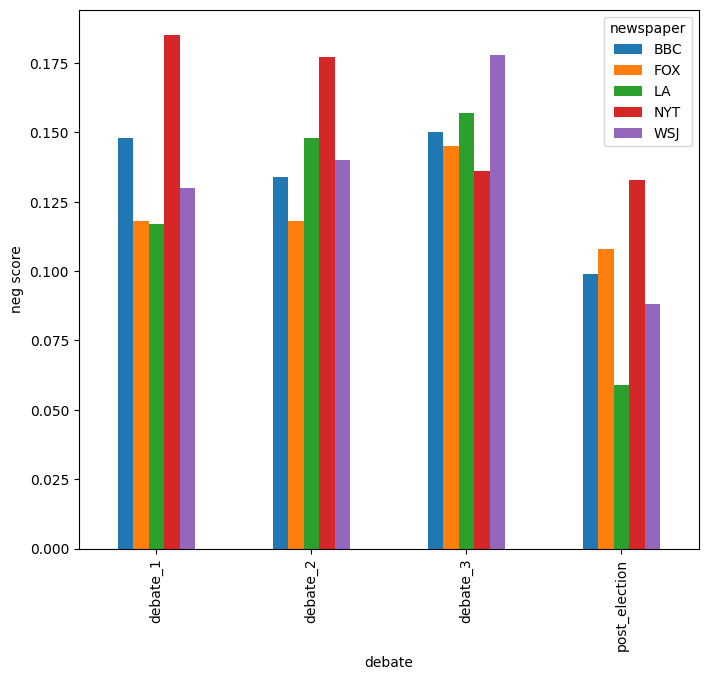

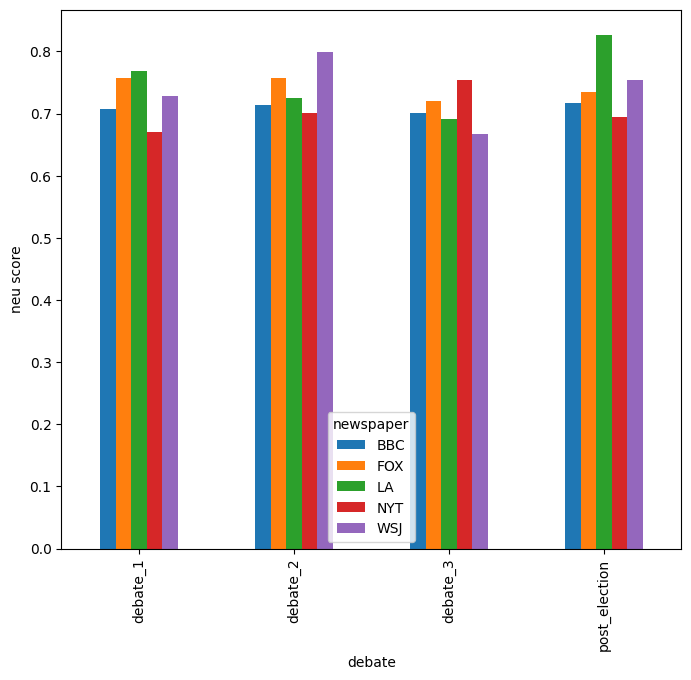

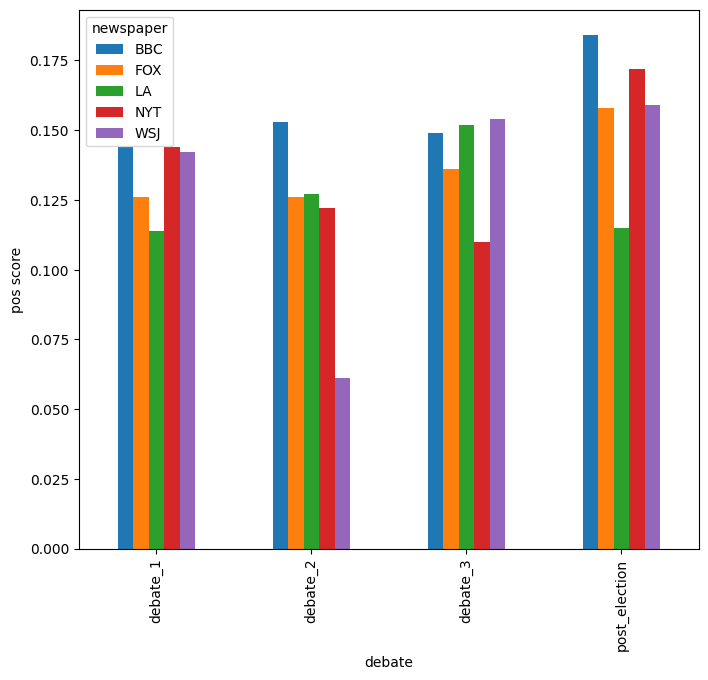

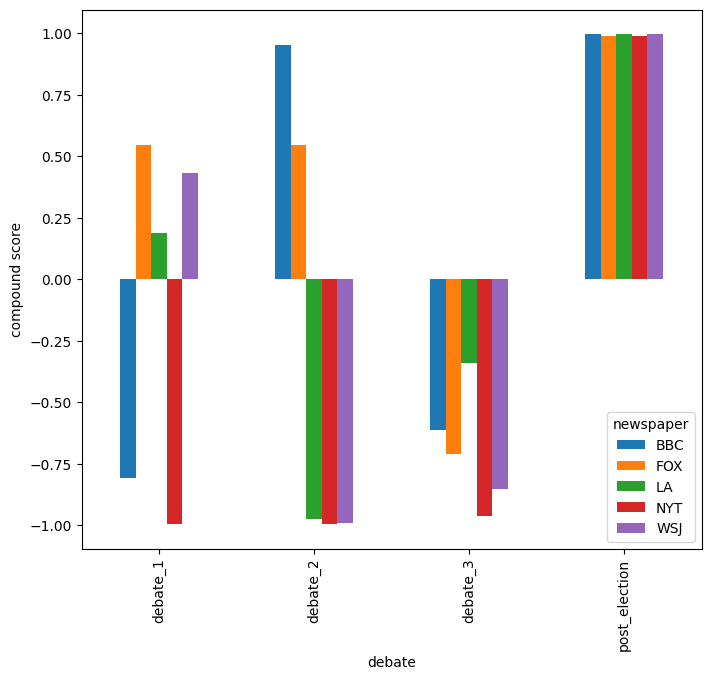

In [ ]:
# Set 'debate' and 'newspaper' columns as multi-index
sentiment_intensity_analyzer_df = sentiment_intensity_analyzer_df.set_index(['debate', 'newspaper'])

for sentiment in ['neg', 'neu', 'pos', 'compound']:
  sentiment_intensity_analyzer_df[sentiment].unstack().plot(kind='bar', figsize=(8,7), ylabel=f'{sentiment} score');



---



## More Specific Sentiment Analysis

In [ ]:
# from nltk.sentiment import SentimentIntensityAnalyzer
# import nltk
# nltk.download('vader_lexicon')


specific_sentiment_intensity_analyzer_dict = {'debate': [],
                                            'newspaper': [],
                                            'Trump': [],
                                            'Clinton': [],
                                            'Republican': [],
                                            'Democratic': []}

sia = SentimentIntensityAnalyzer()
#articles = [article_debate1, article_debate2, article_debate3, article_winning]

entity_sentiments = {'Trump': [], 'Clinton': [], 'Republican': [], 'Democratic': []}

for debate in data.keys():
    print(debate)
    print()

    for newspaper in data[debate].keys():
        print(newspaper)
        # Split article into sentences
        sentences = nltk.sent_tokenize(data[debate][newspaper])
        for sentence in sentences:
          # Check if key entities are in the sentence
          if 'trump' in sentence:
              entity_sentiments['Trump'].append(sia.polarity_scores(sentence))
          if 'clinton' in sentence:
              entity_sentiments['Clinton'].append(sia.polarity_scores(sentence))
          if 'republican' in sentence:
              entity_sentiments['Republican'].append(sia.polarity_scores(sentence))
          if 'democrat' in sentence:
              entity_sentiments['Democratic'].append(sia.polarity_scores(sentence))

        # Now, let's calculate the average sentiment score for each entity
        average_scores = {}
        for entity, scores in entity_sentiments.items():
            total_score = sum(score['compound'] for score in scores)
            average_scores[entity] = total_score / len(scores) if scores else 0


        # appending all to dict for final plotting
        specific_sentiment_intensity_analyzer_dict['debate'].append(debate)
        specific_sentiment_intensity_analyzer_dict['newspaper'].append(newspaper)
        specific_sentiment_intensity_analyzer_dict['Trump'].append(average_scores['Trump'])
        specific_sentiment_intensity_analyzer_dict['Clinton'].append(average_scores['Clinton'])
        specific_sentiment_intensity_analyzer_dict['Republican'].append(average_scores['Republican'])
        specific_sentiment_intensity_analyzer_dict['Democratic'].append(average_scores['Democratic'])

        print(average_scores)

debate_1

BBC
{'Trump': -0.0842655172413793, 'Clinton': -0.043153333333333335, 'Republican': 0.09516666666666664, 'Democratic': 0}
FOX
{'Trump': -0.10057647058823528, 'Clinton': -0.03991764705882353, 'Republican': 0.0019874999999999823, 'Democratic': -0.3672333333333333}
NYT
{'Trump': -0.1005892857142857, 'Clinton': -0.05873116883116883, 'Republican': -0.039522222222222236, 'Democratic': -0.39859999999999995}
WSJ
{'Trump': -0.08525181818181815, 'Clinton': -0.04103399999999999, 'Republican': -0.07567272727272728, 'Democratic': -0.44891999999999993}
LA
{'Trump': -0.09090952380952376, 'Clinton': -0.04601727272727273, 'Republican': -0.15383846153846156, 'Democratic': -0.42894999999999994}
debate_2

BBC
{'Trump': -0.06330671140939594, 'Clinton': -0.04103129770992367, 'Republican': -0.04944375000000002, 'Democratic': -0.42894999999999994}
FOX
{'Trump': -0.07086783625730991, 'Clinton': -0.040238815789473685, 'Republican': -0.0747888888888889, 'Democratic': -0.40837777777777773}
NYT
{'Trump': 

In [ ]:
specific_sentiment_intensity_analyzer_df = pd.DataFrame(specific_sentiment_intensity_analyzer_dict)
specific_sentiment_intensity_analyzer_df

,debate,newspaper,Trump,Clinton,Republican,Democratic
0,debate_1,BBC,-0.084266,-0.043153,0.095167,0.000000
1,debate_1,FOX,-0.100576,-0.039918,0.001987,-0.367233
2,debate_1,NYT,-0.100589,-0.058731,-0.039522,-0.398600
3,debate_1,WSJ,-0.085252,-0.041034,-0.075673,-0.448920
4,debate_1,LA,-0.090910,-0.046017,-0.153838,-0.428950
5,debate_2,BBC,-0.063307,-0.041031,-0.049444,-0.428950
6,debate_2,FOX,-0.070868,-0.040239,-0.074789,-0.408378
7,debate_2,NYT,-0.075123,-0.060095,-0.088924,-0.408378
8,debate_2,WSJ,-0.089376,-0.072364,-0.106732,-0.360175
9,debate_2,LA,-0.083249,-0.081674,-0.104123,-0.369138


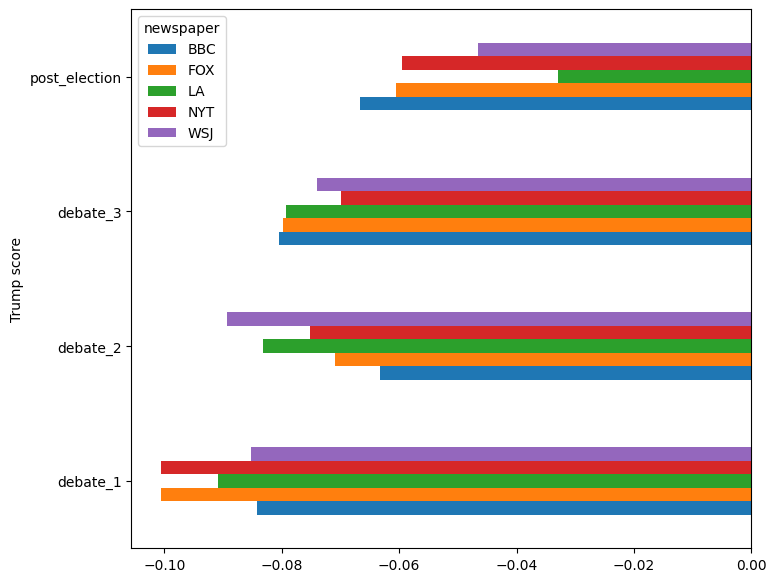

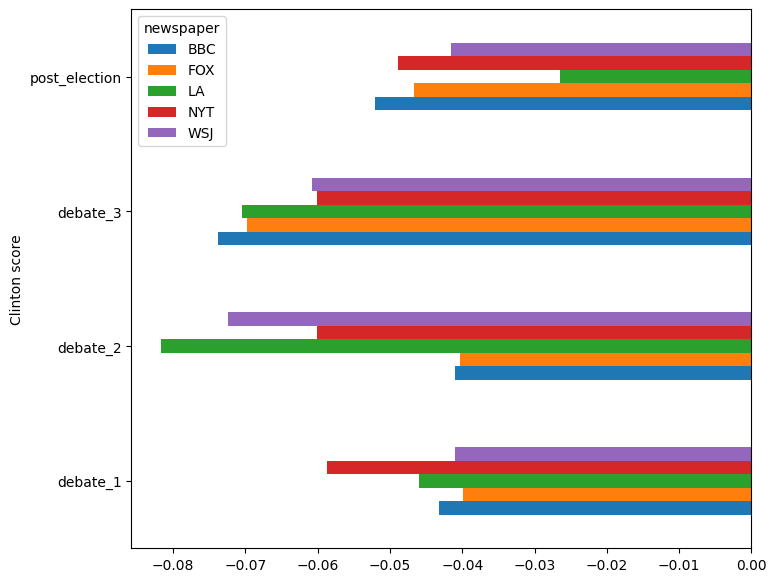

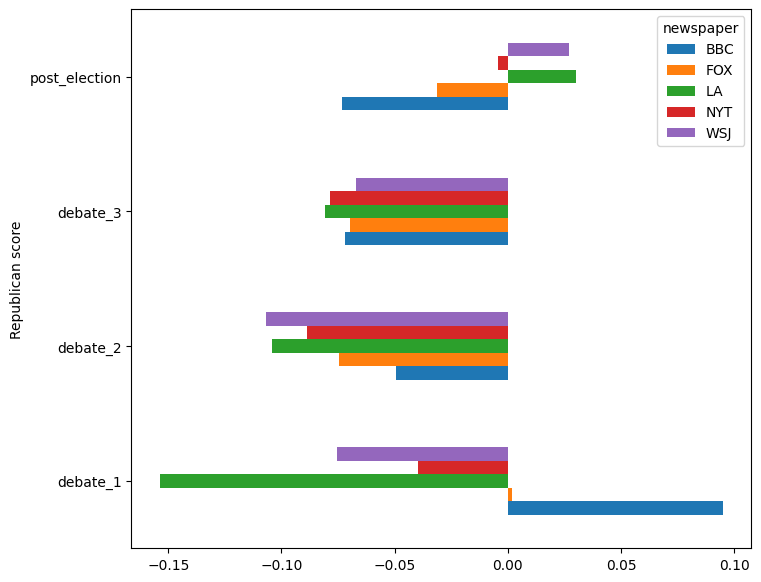

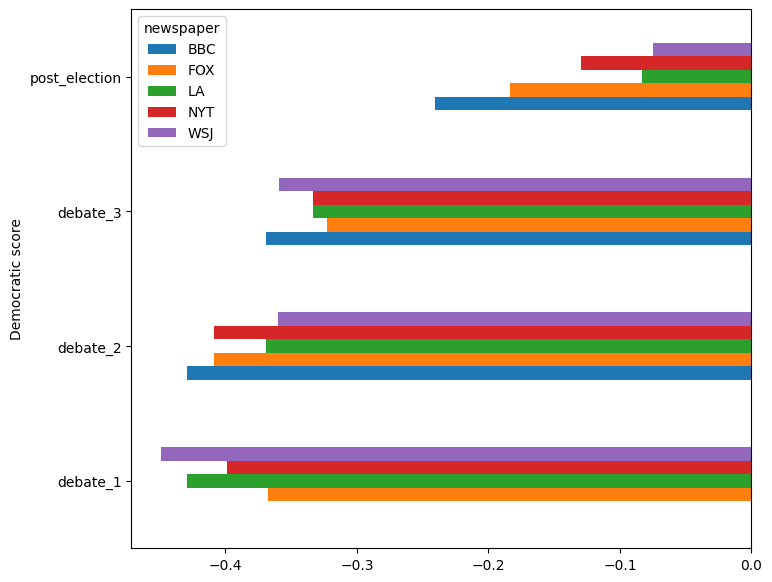

In [ ]:

# Set 'debate' and 'newspaper' columns as multi-index
specific_sentiment_intensity_analyzer_df = specific_sentiment_intensity_analyzer_df.set_index(['debate', 'newspaper'])

for sentiment in ['Trump', 'Clinton', 'Republican', 'Democratic']:
  specific_sentiment_intensity_analyzer_df[sentiment].unstack().plot(kind='barh', figsize=(8,7), ylabel=f'{sentiment} score');



---



## Objectivity & Subjectivity

In [ ]:
objectivity_polarity_dict = {'debate': [],
                                            'newspaper': [],
                                            'Polarity': [],
                                            'Subjectivity': []}


from textblob import TextBlob
for debate in data.keys():
    print(debate)
    print()

    for newspaper in data[debate].keys():
        print(newspaper)
        blob = TextBlob(data[debate][newspaper])
        sentiment = blob.sentiment
        print(f"Sentiment polarity: {sentiment.polarity}, Subjectivity: {sentiment.subjectivity}")

        objectivity_polarity_dict['debate'].append(debate)
        objectivity_polarity_dict['newspaper'].append(newspaper)
        objectivity_polarity_dict['Polarity'].append(sentiment.polarity)
        objectivity_polarity_dict['Subjectivity'].append(sentiment.subjectivity)




debate_1

BBC
Sentiment polarity: 0.0710813088238461, Subjectivity: 0.46115628567121086
FOX
Sentiment polarity: 0.07788957074671363, Subjectivity: 0.3921701314558458
NYT
Sentiment polarity: 0.03885612957304134, Subjectivity: 0.4482342861386979
WSJ
Sentiment polarity: 0.1319010028253726, Subjectivity: 0.4446487079680355
LA
Sentiment polarity: 0.07242202729044833, Subjectivity: 0.5109078251183515
debate_2

BBC
Sentiment polarity: 0.11222795329178306, Subjectivity: 0.4425933089762878
FOX
Sentiment polarity: 0.07788957074671363, Subjectivity: 0.3921701314558458
NYT
Sentiment polarity: 0.053628138528138546, Subjectivity: 0.5150495238095241
WSJ
Sentiment polarity: 0.017975675118532253, Subjectivity: 0.508600214977766
LA
Sentiment polarity: 0.045025807525807496, Subjectivity: 0.4085927960927961
debate_3

BBC
Sentiment polarity: 0.0632238795825752, Subjectivity: 0.4582966831879874
FOX
Sentiment polarity: 0.033046497584541076, Subjectivity: 0.4252113526570049
LA
Sentiment polarity: -0.024401558

In [ ]:
objectivity_polarity_dict_df = pd.DataFrame(objectivity_polarity_dict) # converting the collected dict to a dataframe
objectivity_polarity_dict_df

,debate,newspaper,Polarity,Subjectivity
0,debate_1,BBC,0.071081,0.461156
1,debate_1,FOX,0.077890,0.392170
2,debate_1,NYT,0.038856,0.448234
3,debate_1,WSJ,0.131901,0.444649
4,debate_1,LA,0.072422,0.510908
5,debate_2,BBC,0.112228,0.442593
6,debate_2,FOX,0.077890,0.392170
7,debate_2,NYT,0.053628,0.515050
8,debate_2,WSJ,0.017976,0.508600
9,debate_2,LA,0.045026,0.408593


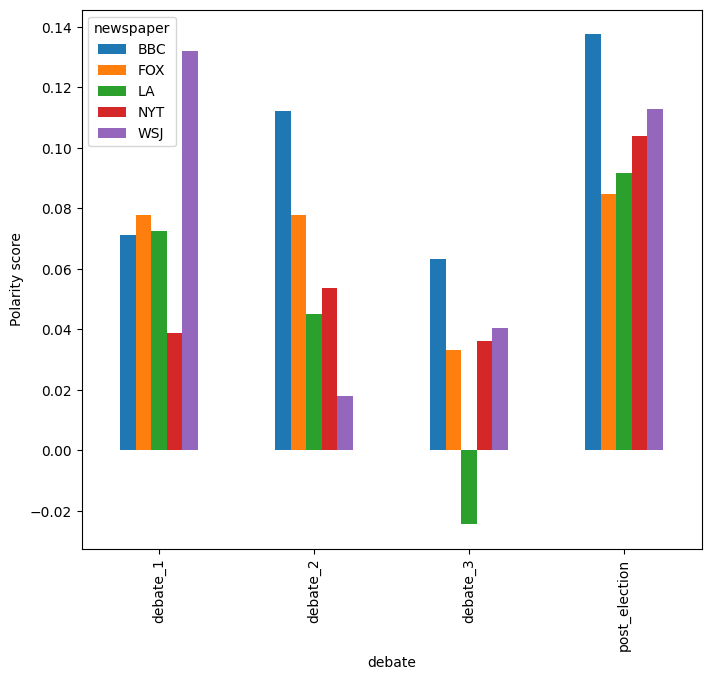

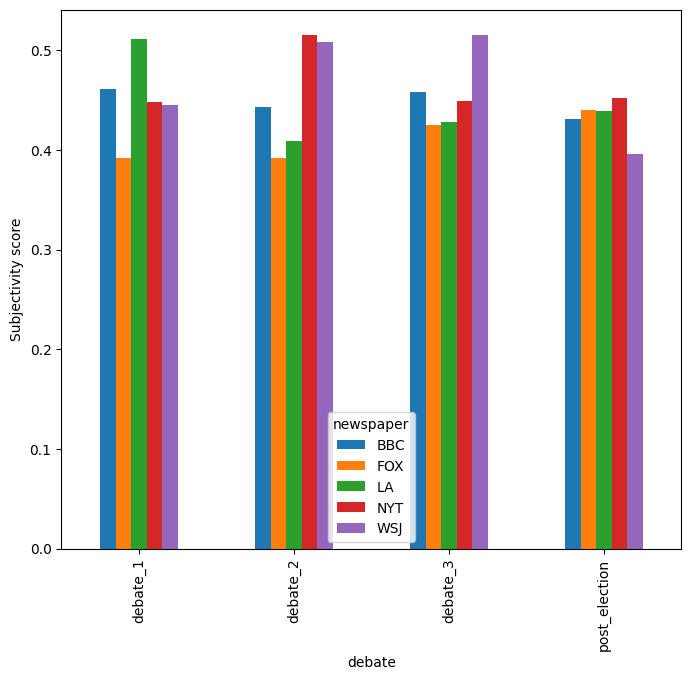

In [ ]:
objectivity_polarity_dict_df = objectivity_polarity_dict_df.set_index(['debate', 'newspaper'])

for sentiment in ['Polarity', 'Subjectivity']:
  objectivity_polarity_dict_df[sentiment].unstack().plot(kind='bar', figsize=(8,7), ylabel=f'{sentiment} score');

In [ ]:
from textblob import TextBlob
for debate in data.keys():
    print(debate)
    print()

    for newspaper in data[debate].keys():
        print(newspaper)
        blob = TextBlob(data[debate][newspaper])
        sentiment = blob.sentiment
        print(f"Sentiment polarity: {sentiment.polarity}, Subjectivity: {sentiment.subjectivity}")

debate_1

BBC
Sentiment polarity: 0.0710813088238461, Subjectivity: 0.46115628567121086
FOX
Sentiment polarity: 0.07788957074671363, Subjectivity: 0.3921701314558458
NYT
Sentiment polarity: 0.03885612957304134, Subjectivity: 0.4482342861386979
WSJ
Sentiment polarity: 0.1319010028253726, Subjectivity: 0.4446487079680355
LA
Sentiment polarity: 0.07242202729044833, Subjectivity: 0.5109078251183515
debate_2

BBC
Sentiment polarity: 0.11222795329178306, Subjectivity: 0.4425933089762878
FOX
Sentiment polarity: 0.07788957074671363, Subjectivity: 0.3921701314558458
NYT
Sentiment polarity: 0.053628138528138546, Subjectivity: 0.5150495238095241
WSJ
Sentiment polarity: 0.017975675118532253, Subjectivity: 0.508600214977766
LA
Sentiment polarity: 0.045025807525807496, Subjectivity: 0.4085927960927961
debate_3

BBC
Sentiment polarity: 0.0632238795825752, Subjectivity: 0.4582966831879874
FOX
Sentiment polarity: 0.033046497584541076, Subjectivity: 0.4252113526570049
LA
Sentiment polarity: -0.024401558



---



## Themes in Documents

In [ ]:
import gensim
from gensim import corpora

# # Prepare Document-Term Matrix
# from textblob import TextBlob
# for debate in data.keys():
#     print(debate)
#     print()

#     for newspaper in data_preprocessed[debate].keys():
#         print(newspaper)
#         #blob = TextBlob(data[debate][newspaper])
#         #sentiment = blob.sentiment
#         #print(f"Sentiment polarity: {sentiment.polarity}, Subjectivity: {sentiment.subjectivity}")
#         dictionary = corpora.Dictionary(data_preprocessed[debate][newspaper]['filtered_tokens'])
#         corpus = [dictionary.doc2bow(token) for token in data_preprocessed[debate][newspaper]['filtered_tokens']]

#         # LDA Model
#         lda_model = gensim.models.ldamodel.LdaModel(corpus, num_topics=3, id2word = dictionary, passes=15)
#         print(lda_model.print_topics())


for debate in data.keys():
    print(debate)
    print()

    for newspaper in data_preprocessed[debate].keys():
        print(newspaper)
        filtered_tokens_lst = [i.split() for i in data_preprocessed[debate][newspaper]['filtered_tokens']]
        dictionary = corpora.Dictionary(filtered_tokens_lst)
        corpus = [dictionary.doc2bow(token) for token in filtered_tokens_lst]

        # LDA Model
        lda_model = gensim.models.ldamodel.LdaModel(corpus, num_topics=3, id2word = dictionary, passes=15)
        print(lda_model.print_topics())


debate_1

BBC
[(0, '0.029*"debate" + 0.011*"foundation" + 0.011*"would" + 0.011*"election" + 0.011*"response" + 0.010*"experience" + 0.008*"say" + 0.008*"question" + 0.008*"way" + 0.008*"even"'), (1, '0.054*"trump" + 0.054*"clinton" + 0.014*"one" + 0.011*"ahead" + 0.007*"first" + 0.007*"came" + 0.007*"called" + 0.007*"topic" + 0.007*"hillary" + 0.007*"much"'), (2, '0.014*"women" + 0.012*"republican" + 0.012*"donald" + 0.010*"american" + 0.008*"asked" + 0.008*"media" + 0.008*"whether" + 0.008*"make" + 0.008*"video" + 0.008*"last"')]
FOX
[(0, '0.071*"trump" + 0.035*"debate" + 0.010*"election" + 0.010*"factset" + 0.008*"democratic" + 0.008*"even" + 0.008*"last" + 0.008*"candidates" + 0.008*"think" + 0.008*"president"'), (1, '0.015*"state" + 0.015*"secretary" + 0.012*"release" + 0.012*"tax" + 0.012*"nominee" + 0.009*"reserved" + 0.009*"week" + 0.009*"stage" + 0.009*"also" + 0.006*"subscribed"'), (2, '0.067*"clinton" + 0.013*"campaign" + 0.013*"bring" + 0.013*"back" + 0.010*"provided" + 0.0

In [ ]:
# Themes per news source without article separation

import gensim
from gensim import corpora
import itertools

# Organize articles by news source
articles_by_source = {}
for debate in data_preprocessed.keys():
    for newspaper, content in data_preprocessed[debate].items():
        if newspaper not in articles_by_source:
            articles_by_source[newspaper] = []
        articles_by_source[newspaper].extend(content['filtered_tokens'])  # Concatenate lists of tokens

# Function to analyze topics with LDA
def lda_analysis(tokens_list):
    dictionary = corpora.Dictionary(tokens_list)
    corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

    # LDA Model
    lda_model = gensim.models.ldamodel.LdaModel(corpus, num_topics=3, id2word=dictionary, passes=15)
    return lda_model.print_topics()

# Analyze each news source
for newspaper, tokens in articles_by_source.items():
    print(f'Analysis for {newspaper}')
    tokens_list = [tokens]  # Wrap tokens in another list if each newspaper is treated as a single document
    topics = lda_analysis(tokens_list)
    for topic in topics:
        print(topic)
    print("-" * 50)


Analysis for BBC
(0, '0.001*"trump" + 0.001*"clinton" + 0.001*"debate" + 0.001*"would" + 0.001*"republican" + 0.001*"us" + 0.001*"one" + 0.001*"video" + 0.001*"women" + 0.001*"exchange"')
(1, '0.026*"trump" + 0.023*"clinton" + 0.012*"debate" + 0.006*"would" + 0.006*"one" + 0.004*"women" + 0.004*"us" + 0.004*"republican" + 0.004*"donald" + 0.004*"election"')
(2, '0.001*"trump" + 0.001*"clinton" + 0.001*"debate" + 0.001*"would" + 0.001*"one" + 0.001*"donald" + 0.001*"women" + 0.001*"republican" + 0.001*"election" + 0.001*"played"')
--------------------------------------------------
Analysis for FOX
(0, '0.001*"trump" + 0.001*"clinton" + 0.001*"debate" + 0.001*"campaign" + 0.001*"election" + 0.001*"provided" + 0.001*"fox" + 0.001*"news" + 0.001*"end" + 0.001*"secretary"')
(1, '0.001*"trump" + 0.001*"clinton" + 0.001*"debate" + 0.001*"campaign" + 0.001*"factset" + 0.001*"provided" + 0.001*"data" + 0.001*"fox" + 0.001*"nominee" + 0.001*"news"')
(2, '0.029*"trump" + 0.027*"clinton" + 0.012*"



---



In [ ]:
from gensim.models.coherencemodel import CoherenceModel

def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    for num_topics in range(start, limit, step):
        model = gensim.models.ldamodel.LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return coherence_values

In [ ]:
coherence_dict = {'debate': [],
                                            'newspaper': [],
                                            'coherence': []}

from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaModel

for debate in data.keys():
    print(debate)
    print()

    for newspaper in data_preprocessed[debate].keys():
        print(newspaper)

        dictionary = corpora.Dictionary([data_preprocessed[debate][newspaper]['filtered_tokens']])
        corpus = [dictionary.doc2bow(token) for token in [data_preprocessed[debate][newspaper]['filtered_tokens']]]

        lda_model = gensim.models.ldamodel.LdaModel(corpus, num_topics=3, id2word = dictionary, passes=15)
        coherence_model_lda = CoherenceModel(model=lda_model, texts=[data_preprocessed[debate][newspaper]['filtered_tokens']], dictionary=dictionary, coherence='c_v')
        coherence_lda = coherence_model_lda.get_coherence()

        coherence_dict['debate'].append(debate)
        coherence_dict['newspaper'].append(newspaper)
        coherence_dict['coherence'].append(coherence_lda)

        print(f"Coherence Score: {coherence_lda}")




debate_1

BBC
Coherence Score: 0.21101381624326354
FOX
Coherence Score: 0.26915940236034813
NYT
Coherence Score: 0.1691464653110221
WSJ
Coherence Score: 0.23437580332452326
LA
Coherence Score: 0.3949738325132264
debate_2

BBC
Coherence Score: 0.2433858444960801
FOX
Coherence Score: 0.245074710720221
NYT
Coherence Score: 0.20703189316917467
WSJ
Coherence Score: 0.2237796045567674
LA
Coherence Score: 0.19771764725525878
debate_3

BBC
Coherence Score: 0.22875542821691663
FOX
Coherence Score: 0.26830259078101254
LA
Coherence Score: 0.21840236903313295
NYT
Coherence Score: 0.20573066643573523
WSJ
Coherence Score: 0.2872479839882987
post_election

BBC
Coherence Score: 0.2990808464755447
FOX
Coherence Score: 0.3077179968586108
NYT
Coherence Score: 0.3208207734869814
WSJ
Coherence Score: 0.2335427273979436
LA
Coherence Score: 0.29590951395606085


In [ ]:
# Coherence aggregated by news sources rather than articles

import gensim
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaModel


# Organize articles by news source
articles_by_source = {}
for debate in data_preprocessed:
    for newspaper, content in data_preprocessed[debate].items():
        if newspaper not in articles_by_source:
            articles_by_source[newspaper] = []
        articles_by_source[newspaper].extend(content['filtered_tokens'])  # Concatenate lists of tokens

# Prepare data structure for coherence scores
coherence_dict = {
    'newspaper': [],
    'coherence': []
}

# Function to analyze topics and calculate coherence
def analyze_topics_and_coherence(tokens):
    dictionary = corpora.Dictionary([tokens])
    corpus = [dictionary.doc2bow(tokens)]

    # LDA Model
    lda_model = gensim.models.ldamodel.LdaModel(corpus, num_topics=3, id2word=dictionary, passes=15)
    coherence_model_lda = CoherenceModel(model=lda_model, texts=[tokens], dictionary=dictionary, coherence='c_v')
    coherence_lda = coherence_model_lda.get_coherence()
    return coherence_lda

# Analyze each news source
for newspaper, tokens in articles_by_source.items():
    print(f'Analysis for {newspaper}')
    coherence_lda = analyze_topics_and_coherence(tokens)
    coherence_dict['newspaper'].append(newspaper)
    coherence_dict['coherence'].append(coherence_lda)

    print(f"Coherence Score: {coherence_lda}")
    print("-" * 50)

Analysis for BBC
Coherence Score: 0.3177762570472334
--------------------------------------------------
Analysis for FOX
Coherence Score: 0.18814914639286387
--------------------------------------------------
Analysis for NYT
Coherence Score: 0.1999689761740997
--------------------------------------------------
Analysis for WSJ
Coherence Score: 0.24667096664123087
--------------------------------------------------
Analysis for LA
Coherence Score: 0.2004709885552507
--------------------------------------------------


In [ ]:
coherence_dict_df = pd.DataFrame(coherence_dict) # converting the collected dict to a dataframe
coherence_dict_df

,newspaper,coherence
0,BBC,0.317776
1,FOX,0.188149
2,NYT,0.199969
3,WSJ,0.246671
4,LA,0.200471


In [ ]:
coherence_dict_df = pd.DataFrame(coherence_dict) # converting the collected dict to a dataframe
coherence_dict_df

,debate,newspaper,coherence
0,debate_1,BBC,0.211014
1,debate_1,FOX,0.269159
2,debate_1,NYT,0.169146
3,debate_1,WSJ,0.234376
4,debate_1,LA,0.394974
5,debate_2,BBC,0.243386
6,debate_2,FOX,0.245075
7,debate_2,NYT,0.207032
8,debate_2,WSJ,0.223780
9,debate_2,LA,0.197718


debate_1

BBC


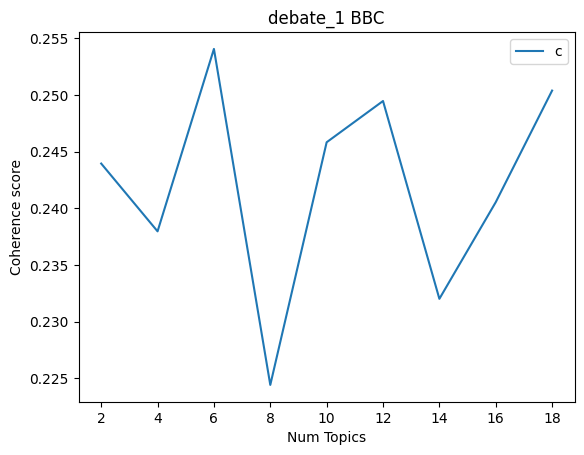

FOX


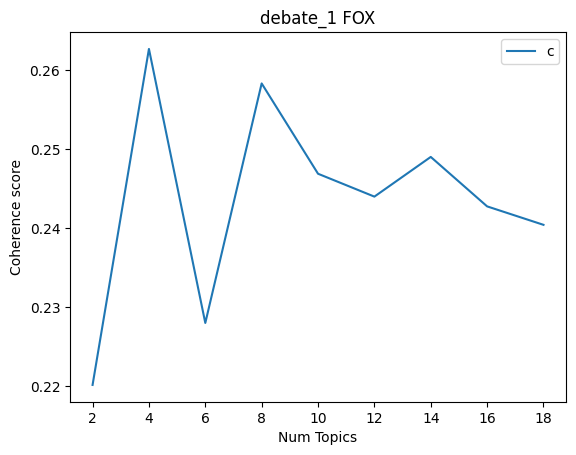

NYT


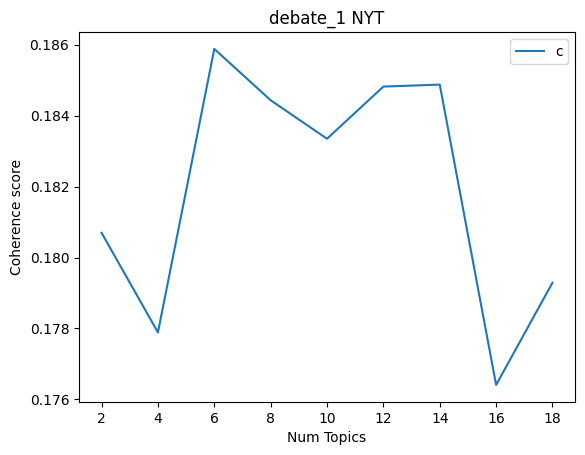

WSJ


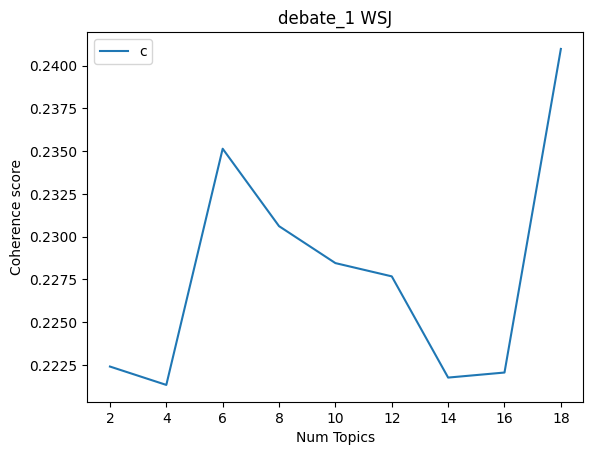

LA


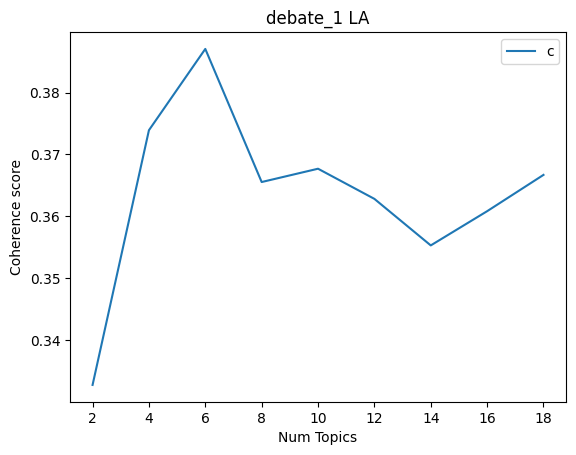

debate_2

BBC


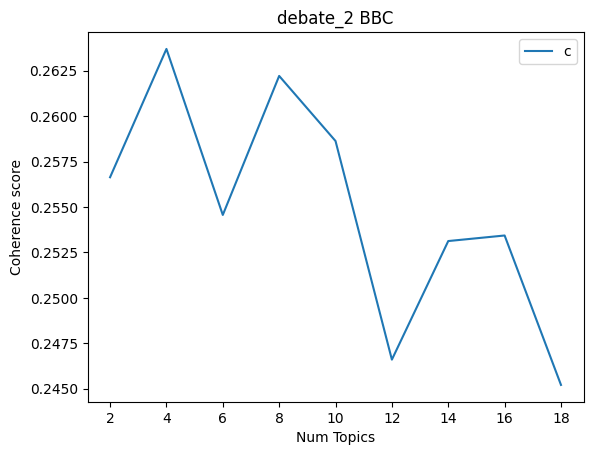

FOX


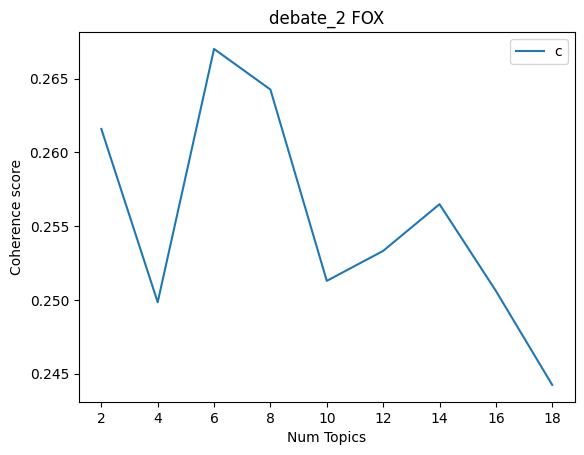

NYT


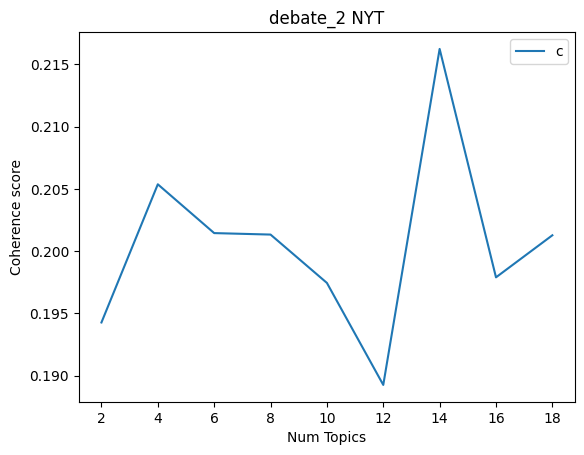

WSJ


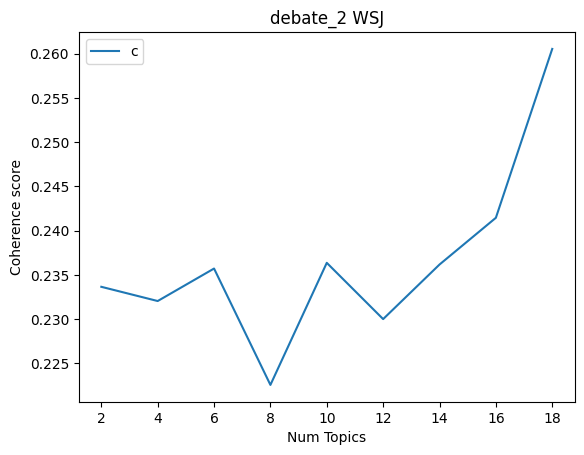

LA


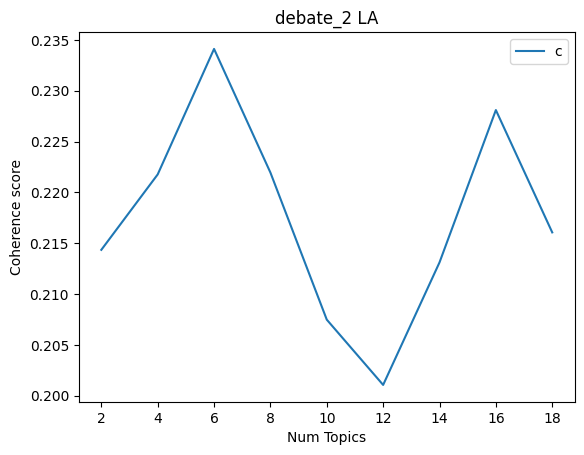

debate_3

BBC


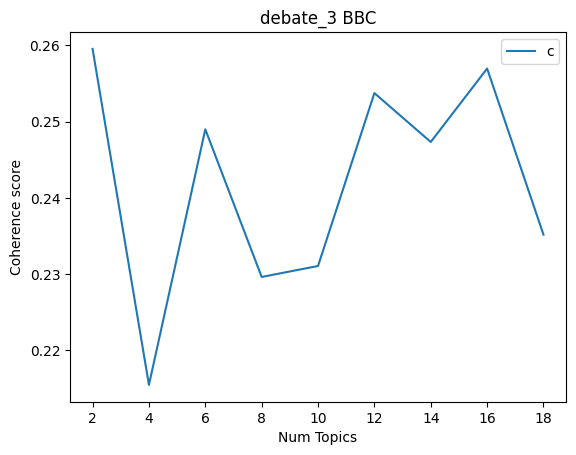

FOX


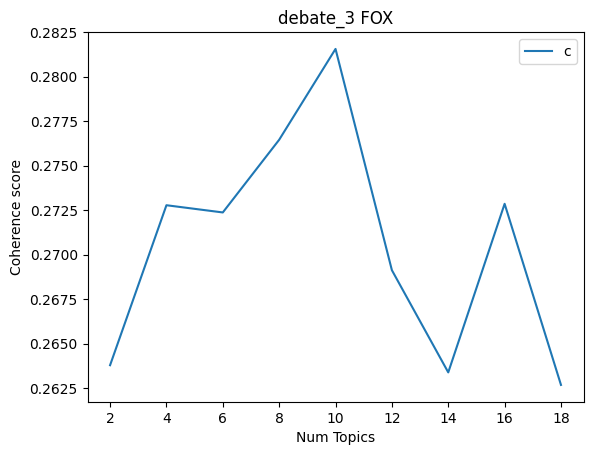

LA


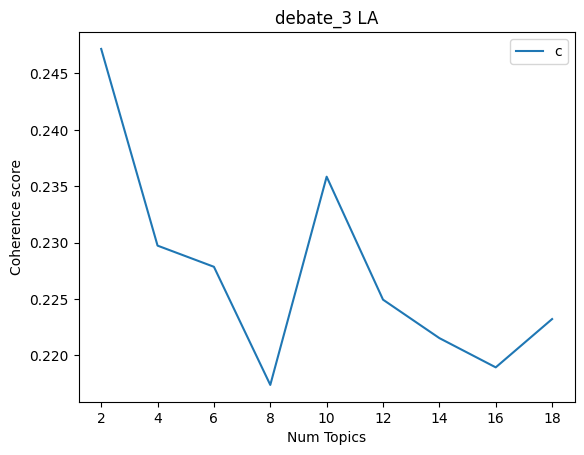

NYT


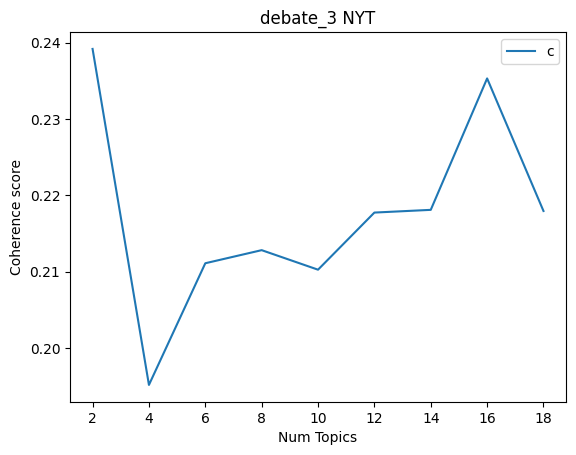

WSJ


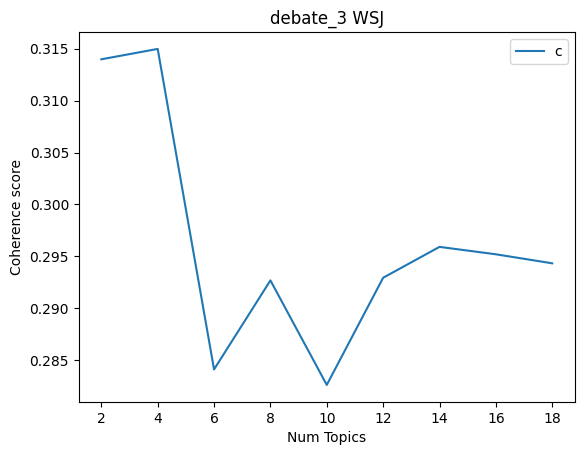

post_election

BBC


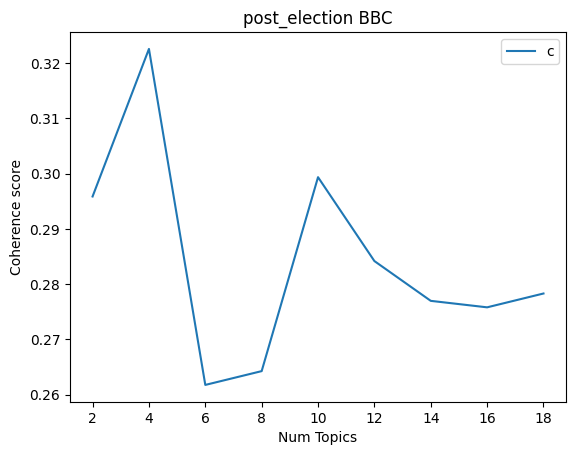

FOX


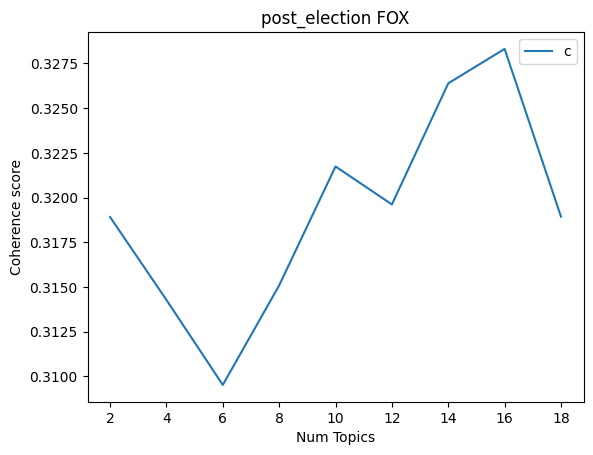

NYT


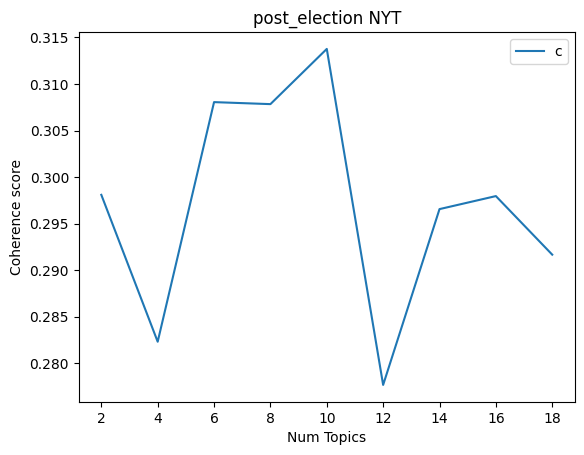

WSJ


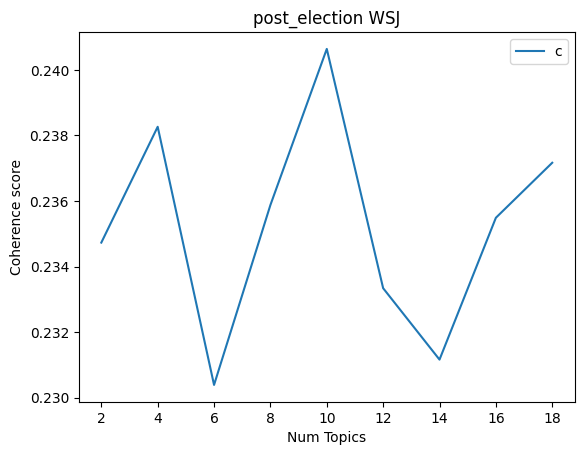

LA


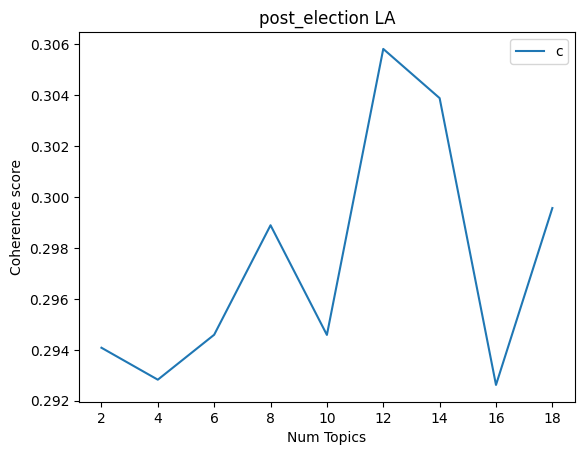

In [ ]:

limit=20; start=2; step=2;

for debate in data.keys():
    print(debate)
    print()

    for newspaper in data_preprocessed[debate].keys():
        print(newspaper)

        dictionary = corpora.Dictionary([data_preprocessed[debate][newspaper]['filtered_tokens']])
        corpus = [dictionary.doc2bow(token) for token in [data_preprocessed[debate][newspaper]['filtered_tokens']]]
        coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=[data_preprocessed[debate][newspaper]['filtered_tokens']], start=start, limit=limit, step=step)

        # # Plot
        x = range(start, limit, step)
        plt.plot(x, coherence_values)
        plt.xlabel("Num Topics")
        plt.title(debate + ' ' + newspaper)
        plt.ylabel("Coherence score")
        plt.legend(("coherence_values"), loc='best')
        plt.show()

In [ ]:
limit=40; start=2; step=3;

for debate in data.keys():
    print(debate)
    print()

    for newspaper in data_preprocessed[debate].keys():
        print(newspaper)
        dictionary = corpora.Dictionary([data_preprocessed[debate][newspaper]['filtered_tokens']])
        corpus = [dictionary.doc2bow(token) for token in [data_preprocessed[debate][newspaper]['filtered_tokens']]]


        # compute coherence values
        coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=[data_preprocessed[debate][newspaper]['filtered_tokens']], start=start, limit=limit, step=step)
        print(coherence_values)


debate_1

BBC


[0.25632704974398024, 0.22364357992038192, 0.2556052300549224, 0.2595257297357465, 0.248272561662245, 0.2389832541719019, 0.2466510495864293, 0.24127167735283536, 0.23682061827672277, 0.24629055302091235, 0.24398560649868795, 0.2311004349427015, 0.28315629227315486]
FOX


[0.25130257040635956, 0.2489111300471351, 0.24133428898296447, 0.2386347863877843, 0.2715465392271779, 0.25756021637445403, 0.24044459450929256, 0.24839479686885538, 0.25042208334656285, 0.2510927248832542, 0.2482990152220809, 0.2667656664638455, 0.2713411713671143]
NYT


[0.17585631857394549, 0.18740469188180675, 0.1852278340562398, 0.1932993988967036, 0.18386934323779242, 0.1811575369967297, 0.18678595475047816, 0.1862116363561373, 0.19369998737525868, 0.2041848363300898, 0.17572887528591719, 0.1894055663678169, 0.2334636754181058]
WSJ


[0.21946055692917985, 0.236884524175741, 0.22788902056850813, 0.22061560751784148, 0.22847783063534485, 0.23181235201601194, 0.22732022354037498, 0.23279271485813433, 0.2555908971518383, 0.2381352730524601, 0.24030998996316666, 0.2366288492155144, 0.26345426936784455]
LA


...

[0.2966205835530335, 0.2767120740338625, 0.28408074237173025, 0.29044149966277405, 0.2901908087962865, 0.2816227881965409, 0.27565567800166574, 0.2867797239259244, 0.28727637874687934, 0.2896066520644532, 0.2949878421748664, 0.29945352918435764, 0.3316001575590251]
FOX


[0.353974172833843, 0.3539786734414339, 0.3164888552042483, 0.32787831432163117, 0.3076020740366134, 0.301888152618448, 0.3130099149014379, 0.3355146895303597, 0.3027622852997499, 0.32223298090637503, 0.34794043023817295, 0.3295549451884999, 0.32679484848414075]
NYT


[0.29047025647843, 0.3202925472928655, 0.2800509648491807, 0.2886795489763158, 0.2940475122171722, 0.29403876459138667, 0.31232210271219674, 0.2854810129639616, 0.2795043878515411, 0.3036480689265125, 0.3115045997722338, 0.2971859733637362, 0.3130660010403381]
WSJ


[0.2257378345835856, 0.23111706181721609, 0.23535850785127815, 0.23333979629256374, 0.23761196623630662, 0.2402052022253006, 0.24154451915721445, 0.23703286105071195, 0.23681524650049302, 0.24155541459919497, 0.23928301116648107, 0.24994285555493276, 0.24041219035788555]
LA


[0.29353510057206195, 0.29183436682171726, 0.2928816745527717, 0.3009095452926782, 0.3105917129869888, 0.3044986089833417, 0.30056366984632044, 0.29111779518818226, 0.29235285381593584, 0.29589114229525826, 0.29606820132369704, 0.3003742198814141, 0.30308374921875975]


Analysis for BBC


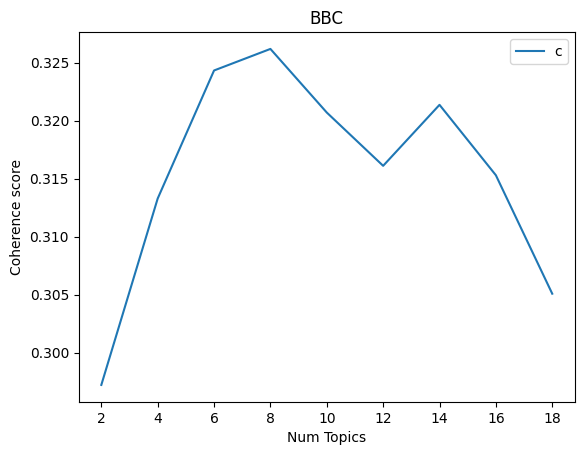

Analysis for FOX


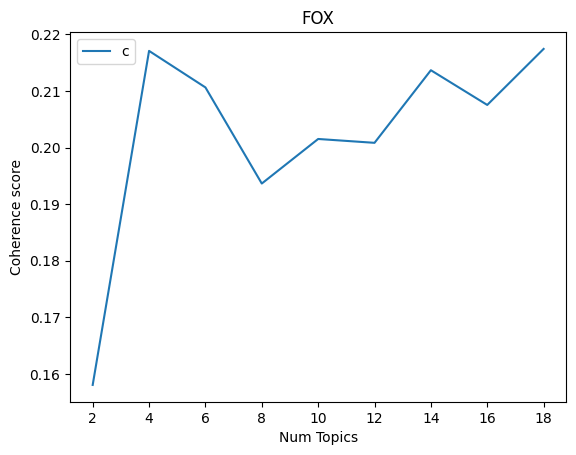

Analysis for NYT


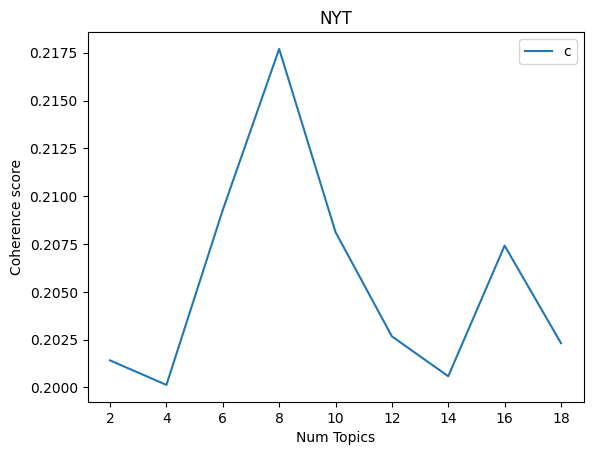

Analysis for WSJ


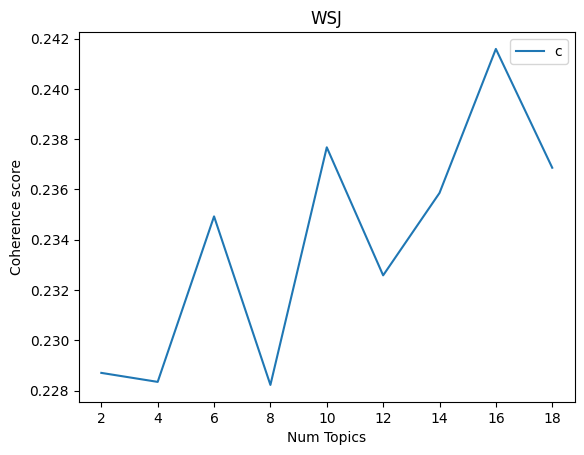

Analysis for LA


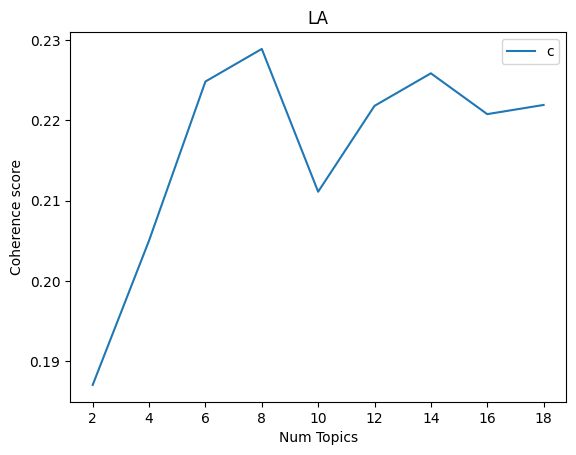

In [ ]:
import gensim
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaModel
import matplotlib.pyplot as plt


# Organize articles by news source
articles_by_source = {}
for debate in data_preprocessed:
    for newspaper, content in data_preprocessed[debate].items():
        if newspaper not in articles_by_source:
            articles_by_source[newspaper] = []
        articles_by_source[newspaper].extend(content['filtered_tokens'])  # Concatenate lists of tokens

# Function to compute coherence values for different numbers of topics
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    for num_topics in range(start, limit, step):
        model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return coherence_values

# Parameters
limit = 20; start = 2; step = 2;

# Analyze each news source
for newspaper, tokens in articles_by_source.items():
    print(f'Analysis for {newspaper}')

    # Prepare the dictionary and corpus
    dictionary = corpora.Dictionary([tokens])
    corpus = [dictionary.doc2bow(tokens)]

    # Compute coherence values
    coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=[tokens], start=start, limit=limit, step=step)

    # Plot
    x = range(start, limit, step)
    plt.plot(x, coherence_values)
    plt.xlabel("Num Topics")
    plt.title(newspaper)
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()

In [ ]:
import gensim
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaModel


# Organize articles by news source
articles_by_source = {}
for debate in data_preprocessed:
    for newspaper, content in data_preprocessed[debate].items():
        if newspaper not in articles_by_source:
            articles_by_source[newspaper] = []
        articles_by_source[newspaper].extend(content['filtered_tokens'])  # Concatenate lists of tokens

# Function to compute coherence values for different numbers of topics
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    for num_topics in range(start, limit, step):
        model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return coherence_values

# Parameters
limit = 40; start = 2; step = 3;

# Analyze each news source
for newspaper, tokens in articles_by_source.items():
    print(f'Analysis for {newspaper}')

    # Prepare the dictionary and corpus
    dictionary = corpora.Dictionary([tokens])
    corpus = [dictionary.doc2bow(tokens)]

    # Compute coherence values
    coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=[tokens], start=start, limit=limit, step=step)

    print(coherence_values)

Analysis for BBC


[0.2854325618201893, 0.3249416170521213, 0.31803130639563265, 0.2999321095815516, 0.3165555027133933, 0.32322908099913256, 0.3175055245562183, 0.312929186855391, 0.31167846752848904, 0.31250539933713256, 0.3100036929853501, 0.3194652328437442, 0.3124245638577336]
Analysis for FOX


[0.2535826679637655, 0.1984314022426351, 0.2135848501896579, 0.17680028465196115, 0.21640500712196278, 0.20902585302107282, 0.21916196796609494, 0.23091049176699577, 0.21561308370404955, 0.20641354607761928, 0.2034275891483791, 0.2086144560063416, 0.2186732945757224]
Analysis for NYT


[0.20931271560403947, 0.20502340882694003, 0.20179168337271258, 0.2092369398204198, 0.2097947749683737, 0.19671653754915303, 0.20774051346807404, 0.20211960633338483, 0.20806354923165168, 0.19960034589911516, 0.20493419798191195, 0.20189883184901578, 0.20745478069360565]
Analysis for WSJ


[0.24111325712588674, 0.24668999816282566, 0.22491855159444302, 0.23001716261474908, 0.23452822410997332, 0.233017035894565, 0.2369023911115252, 0.23944973613659756, 0.24107646721678236, 0.23836873943326498, 0.23940351138443727, 0.23664861739708906, 0.23575310908484495]
Analysis for LA


[0.22074116329115906, 0.21872549790730958, 0.2080362323573982, 0.22767508351756008, 0.21182795467963147, 0.22071210053943197, 0.21401484006829546, 0.2206402639945862, 0.21537368155714198, 0.2209820528041415, 0.21891568927534327, 0.21978723298836425, 0.223089442419299]




---



In [ ]:
!pip install pyLDAvis


import pyLDAvis.gensim


import matplotlib.pyplot as plt
import gensim
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis


def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    models = []
    for num_topics in range(start, limit, step):
        model = gensim.models.ldamodel.LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary)
        models.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return models, coherence_values

limit=20; start=2; step=2;
models, coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=filtered_tokens_w, start=start, limit=limit, step=step)

# Elbow Plot
x = range(start, limit, step)
plt.figure(figsize=(10,5))
plt.plot(x, coherence_values, marker='o')
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.title("Coherence Score vs. Number of Topics")
plt.show()

# Choose the model with the "elbow" number of topics and visualize it
optimal_model = models[coherence_values.index(max(coherence_values))]  # This is a simplification; in practice, you'd look for the "elbow"
vis = gensimvis.prepare(optimal_model, corpus, dictionary)
pyLDAvis.display(vis)